## LangGraph Tools - Chatbot with Multiple Tools

In [1]:
## tools

import arxiv
import wikipedia
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

C:\Users\Nitish\AppData\Local\Temp\ipykernel_13508\921746096.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
# 1. Apply compatibility patch for arxiv >= 2.0.0
if not hasattr(arxiv.Search, "results"):
  arxiv.Search.results = lambda self: arxiv.Client().results(self)

In [3]:
# 2. Set user agent for wikipedia requests
wikipedia.set_user_agent("MyLangGraphApp/1.0 (contact@example.com)")

In [4]:
# 3. Create Arxiv tool
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv_tool = ArxivQueryRun(
    api_wrapper=api_wrapper_arxiv, description="Query arxiv papers"
)

In [ ]:
# Test arxiv invocation
print(arxiv_tool.invoke("Attention is all you need."))

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [10]:
# 4. FIX FOR WIKIPEDIA: Set a custom browser User-Agent to avoid HTTP 403 Forbidden
wikipedia.set_user_agent(
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like"
    " Gecko) Chrome/120.0.0.0 Safari/537.36"
)

In [11]:
# 5. Create wikipedia tool
api_wrapper_wiki = WikipediaAPIWrapper(
    top_k_results=2, doc_content_chars_max=500
)
wiki_tool = WikipediaQueryRun(
    api_wrapper=api_wrapper_wiki, description="Query wikipedia articles"
)
wiki_tool.name

'wikipedia'

In [12]:
# Test wikipedia tool
print(wiki_tool.invoke("India"))

Page: India
Summary: India, officially the Republic of India, is a country in South Asia.  It is the world's seventh-largest country by area and the largest by population. Bounded by the Indian Ocean on the south, the Arabian Sea on the southwest, and the Bay of Bengal on the southeast, it shares land borders with Pakistan to the west; China, Nepal, and Bhutan to the north; and Bangladesh and Myanmar to the east. In the Indian Ocean, India is near Sri Lanka and the Maldives.
Modern humans arrive


In [13]:
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [16]:
# Tavily search tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults()

In [17]:
# Test Tavily serach tool
tavily_tool.invoke("Today AI news")

[{'title': 'Meta Open-Sources Muse Glimmer: AI News August 11 2026',
  'url': 'https://www.buildfastwithai.com/blogs/ai-news-today-august-11-2026',
  'content': "## Frequently Asked Questions About Today's AI News\n\n### What is Meta Muse Glimmer?\n\nMuse Glimmer is Meta's new open-weight AI model, released August 10, 2026, a compact system built for agentic tasks that can run locally on a Mac or PC with a single graphics card, reported as roughly 30 billion parameters. Being open-weight, anyone can download, run, and customize it.\n\n### Can Muse Glimmer run on a laptop?\n\nYes. Muse Glimmer is designed to run locally on a Mac or PC with a single graphics card, making capable agentic AI runnable on ordinary hardware without cloud infrastructure. That lets developers keep data private and avoid ongoing per-token cloud costs.\n\n### Is Meta open-sourcing its AI models? [...] The deeper threads continue to develop. The open-versus-closed battle will keep intensifying as Meta and Chinese 

In [27]:
## Combine all these tools in the list
tools = [arxiv_tool, wiki_tool, tavily_tool]

In [24]:
## Intialize the LLM Model
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")

In [25]:
llm.invoke("What is AI?")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Query**: The user asks "What is AI?" - a broad, fundamental question about Artificial Intelligence.\n\n2.  **Identify Key Components to Cover**:\n   - Definition of AI\n   - Core concepts/types (Narrow vs. General vs. Super AI)\n   - How it works (machine learning, neural networks, data)\n   - Applications/examples\n   - Current state & limitations\n   - Ethical/societal considerations (briefly)\n   - Keep it clear, concise, and accessible\n\n3.  **Draft - Mental Refinement**:\n   AI stands for Artificial Intelligence. It refers to computer systems designed to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, understanding language, and recognizing patterns. \n   \n   There are different types: Narrow AI (specialized for specific tasks like voice assistants or recommendation systems), Artificial General Intelligence (AGI, hypothetical systems with huma

In [30]:
# Bind LLM with tools
llm_with_tools = llm.bind_tools(tools=tools)

In [32]:
## Execute tool call through LLM
llm_with_tools.invoke("what is the recent new on ai?")

AIMessage(content='', additional_kwargs={'reasoning_content': "I will search for recent news about artificial intelligence using a search engine.\nFinally, I will answer the user's question about the recent news on AI.\n", 'tool_calls': [{'id': 'w1909qshr', 'function': {'arguments': '{"query":"recent news on artificial intelligence"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 443, 'total_tokens': 510, 'completion_time': 0.131340013, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.036404874, 'prompt_tokens_details': None, 'queue_time': 0.054492835, 'total_time': 0.167744887}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_60e0d2f248', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff261-ee53-7c83-9dd9-6a76a6181c98-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'quer

## Create workflow

In [35]:
## Import required things
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ## Human message or AI message
from typing import Annotated ## labelling
from langgraph.graph.message import add_messages ## Reducers in Langgraph


In [34]:
## State Schema
class State(TypedDict):
  messages: Annotated[list[AnyMessage], add_messages]

In [36]:
### Entire Chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

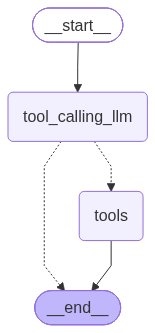

In [38]:
### Node defnition
def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Schedule the flow of the graph using edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm", 
  # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  # If the latest messgae (result) from assistant is not a tool call -> tools_condition routes to llm
  tools_condition
)
builder.add_edge("tools", END)

# Compile it
graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
# Call the chatbot
messages = graph.invoke({"messages": "What is today's ai news?"})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is today's ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (67jdq2cdw)
 Call ID: 67jdq2cdw
  Args:
    query: today's AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News: An INSANE Week… Here's What Matters - YouTube", "url": "https://www.youtube.com/watch?v=nydHKXjwu0U", "content": "# AI News: An INSANE Week… Here’s What Matters\n## Matt Wolfe\n993000 subscribers\n2939 likes\n\n### Description\n101465 views\nPosted: 12 Jun 2026\nHere's the AI News you probably missed this week.\n\nDiscover More:\n🛠️ Explore AI Tools & News: \n📰 Weekly Newsletter: \n\nSocials:\n❌ Twiter/X: \n🖼️ Instagram: \n🧵 Threads: \n🟦 LinkedIn: \n👍 Facebook: \n\nResources From Today's Video:\nClaude Fable & Mythos 5: \nAnthropic Downgrade Transparency: \nCube

In [44]:
# Call the chatbot
messages = graph.invoke({"messages": "Hi, my name is Nitish"})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi, my name is Nitish
================================== Ai Message ==================================

Hello Nitish! It's nice to meet you. How can I help you today?
